# 🏁 Model 12 — The Ultimate XGBoost Master Report (6-Model Showdown)

This notebook contains a project-wide comparison of 6 different XGBoost strategies across Balanced (SMOTE) and Unbalanced (Original) datasets.

### The Matrix:
1. **Baseline** (Raw Features, 100 est, depth 6)
2. **Advanced** (Raw + V-PCA + Clusters, 100 est, depth 6)
3. **Champion** (Raw + V-PCA + Clusters, 400 est, depth 9, learning_rate 0.03)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_recall_curve, auc, roc_auc_score, confusion_matrix

# Load data
train_smote = pd.read_csv('../data/train_balanced.csv')
train_orig  = pd.read_csv('../data/train_unbalanced.csv')
test        = pd.read_csv('../data/test.csv')

# Universal Column Dropper
DROP_COLS = ['isFraud', 'TransactionID']

y_test = test['isFraud']
X_test_raw = test.drop(columns=[c for c in DROP_COLS if c in test.columns])

results = {}

## 🛠️ Feature Engineering Helper

In [2]:
def apply_advanced_fe(df_train, df_test_raw):
    # Ensure both have the exact same columns
    X_tr = df_train.drop(columns=[c for c in DROP_COLS if c in df_train.columns])
    X_te = df_test_raw.copy()
    
    # Align columns just in case
    common_cols = [c for c in X_tr.columns if c in X_te.columns]
    X_tr = X_tr[common_cols]
    X_te = X_te[common_cols]
    
    # 1. PCA on V-features (95% variance)
    v_cols = [c for c in X_tr.columns if c.startswith('V')]
    scaler = StandardScaler()
    v_tr = scaler.fit_transform(X_tr[v_cols])
    v_te = scaler.transform(X_te[v_cols])
    
    pca = PCA(n_components=0.95, random_state=42)
    v_pca_tr = pca.fit_transform(v_tr)
    v_pca_te = pca.transform(v_te)
    
    # 2. KMeans Clusters
    kmeans = MiniBatchKMeans(n_clusters=8, random_state=42)
    cl_tr = kmeans.fit_predict(X_tr[['TransactionAmt', 'Transaction_Hour']])
    cl_te = kmeans.predict(X_te[['TransactionAmt', 'Transaction_Hour']])
    
    # 3. Combine
    pca_cols = [f'V_PCA_{i}' for i in range(v_pca_tr.shape[1])]
    X_tr_final = pd.concat([X_tr.reset_index(drop=True), pd.DataFrame(v_pca_tr, columns=pca_cols), pd.Series(cl_tr, name='cluster_id')], axis=1)
    X_te_final = pd.concat([X_te.reset_index(drop=True), pd.DataFrame(v_pca_te, columns=pca_cols), pd.Series(cl_te, name='cluster_id')], axis=1)
    
    return X_tr_final, X_te_final

def evaluate_model(name, model, X_tr, y_tr, X_te):
    print(f"\n{'='*20}\nTRAINING: {name}\n{'='*20}")
    model.fit(X_tr, y_tr)
    
    probs = model.predict_proba(X_te)[:, 1]
    preds = model.predict(X_te)
    
    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_test, preds))
    
    pr, rc, _ = precision_recall_curve(y_test, probs)
    pr_auc = auc(rc, pr)
    roc_auc = roc_auc_score(y_test, probs)
    
    results[name] = {
        'pr': pr, 'rc': rc, 'pr_auc': pr_auc, 
        'roc_auc': roc_auc, 'cm': confusion_matrix(y_test, preds)
    }
    
    print(f"PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f}")
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(results[name]['cm'], annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

## 🔵 Group A — Balanced Data (SMOTE)

In [3]:
print("Preparing Balanced Data Features...")
X_train_smote_adv, X_test_smote_adv = apply_advanced_fe(train_smote, X_test_raw)
y_train_smote = train_smote['isFraud']

Preparing Balanced Data Features...



TRAINING: A1: Baseline SMOTE



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.76      0.56      0.65      4133

    accuracy                           0.98    118108
   macro avg       0.87      0.78      0.82    118108
weighted avg       0.98      0.98      0.98    118108

PR-AUC: 0.6755 | ROC-AUC: 0.9343


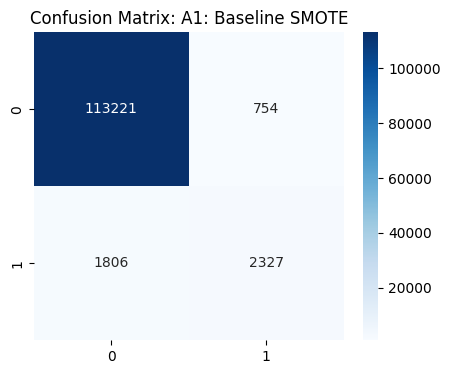

In [4]:
evaluate_model("A1: Baseline SMOTE", 
               XGBClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1), 
               train_smote.drop(columns=[c for c in DROP_COLS if c in train_smote.columns]), y_train_smote, X_test_raw)


TRAINING: A2: Advanced SMOTE



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.74      0.57      0.64      4133

    accuracy                           0.98    118108
   macro avg       0.86      0.78      0.82    118108
weighted avg       0.98      0.98      0.98    118108

PR-AUC: 0.6726 | ROC-AUC: 0.9374


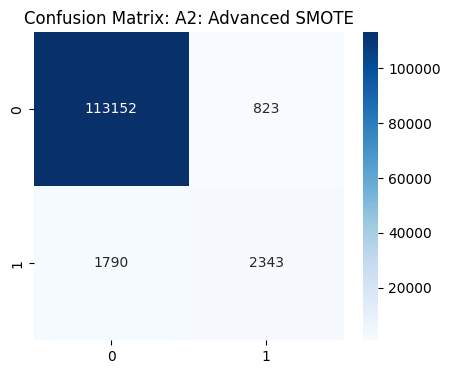

In [5]:
evaluate_model("A2: Advanced SMOTE", 
               XGBClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1), 
               X_train_smote_adv, y_train_smote, X_test_smote_adv)


TRAINING: A3: Champion SMOTE



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.78      0.57      0.66      4133

    accuracy                           0.98    118108
   macro avg       0.88      0.78      0.82    118108
weighted avg       0.98      0.98      0.98    118108

PR-AUC: 0.6956 | ROC-AUC: 0.9440


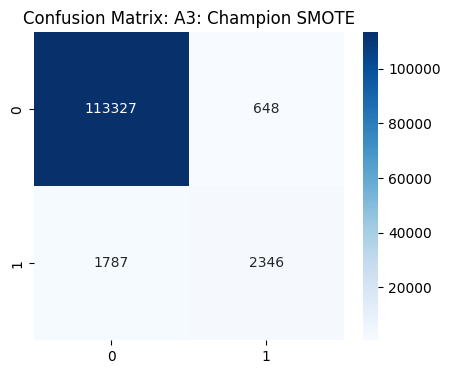

In [6]:
evaluate_model("A3: Champion SMOTE", 
               XGBClassifier(n_estimators=400, max_depth=9, learning_rate=0.03, random_state=42, n_jobs=-1), 
               X_train_smote_adv, y_train_smote, X_test_smote_adv)

## 🔴 Group B — Unbalanced Data (Original + Weighting)

In [7]:
print("Preparing Original Data Features...")
X_train_orig_adv, X_test_orig_adv = apply_advanced_fe(train_orig, X_test_raw)
y_train_orig = train_orig['isFraud']
ratio = (y_train_orig == 0).sum() / (y_train_orig == 1).sum()
print(f"Using scale_pos_weight: {ratio:.2f}")

Preparing Original Data Features...


Using scale_pos_weight: 27.58



TRAINING: B1: Baseline Original



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.99      0.92      0.96    113975
           1       0.27      0.83      0.41      4133

    accuracy                           0.92    118108
   macro avg       0.63      0.87      0.68    118108
weighted avg       0.97      0.92      0.94    118108

PR-AUC: 0.6741 | ROC-AUC: 0.9458


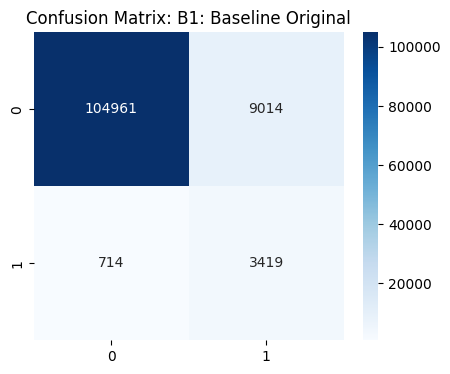

In [8]:
evaluate_model("B1: Baseline Original", 
               XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=ratio, random_state=42, n_jobs=-1), 
               train_orig.drop(columns=[c for c in DROP_COLS if c in train_orig.columns]), y_train_orig, X_test_raw)


TRAINING: B2: Advanced Original



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.99      0.93      0.96    113975
           1       0.29      0.82      0.43      4133

    accuracy                           0.92    118108
   macro avg       0.64      0.87      0.70    118108
weighted avg       0.97      0.92      0.94    118108

PR-AUC: 0.6723 | ROC-AUC: 0.9430


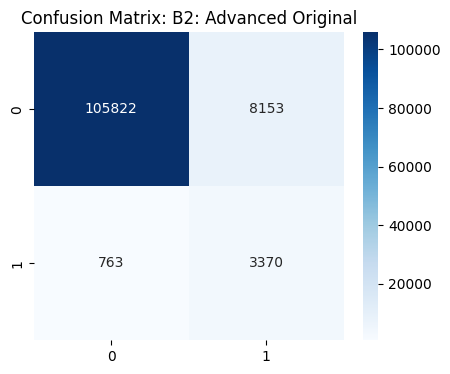

In [9]:
evaluate_model("B2: Advanced Original", 
               XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=ratio, random_state=42, n_jobs=-1), 
               X_train_orig_adv, y_train_orig, X_test_orig_adv)


TRAINING: B3: Champion Original



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97    113975
           1       0.37      0.80      0.50      4133

    accuracy                           0.94    118108
   macro avg       0.68      0.87      0.74    118108
weighted avg       0.97      0.94      0.95    118108

PR-AUC: 0.7107 | ROC-AUC: 0.9514


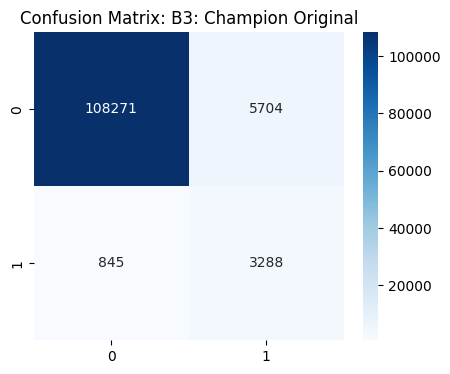

In [10]:
evaluate_model("B3: Champion Original", 
               XGBClassifier(n_estimators=400, max_depth=9, learning_rate=0.03, scale_pos_weight=ratio, random_state=42, n_jobs=-1), 
               X_train_orig_adv, y_train_orig, X_test_orig_adv)

## 📊 Final Performance Comparison

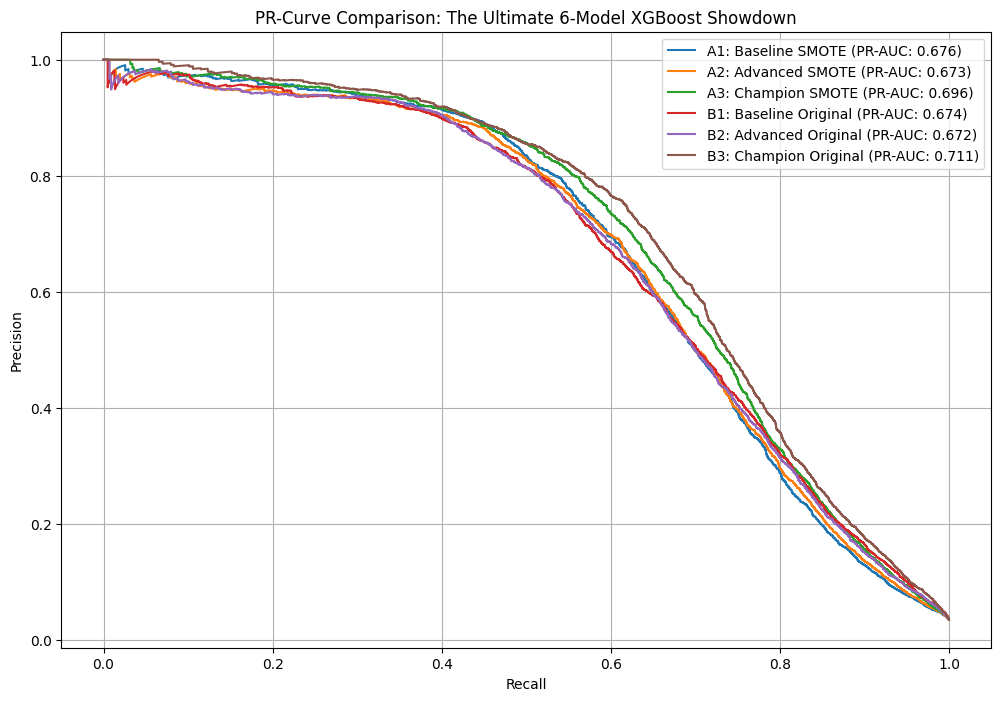

--- LEADERBOARD ---
1. B3: Champion Original: 0.7107
2. A3: Champion SMOTE: 0.6956
3. A1: Baseline SMOTE: 0.6755
4. B1: Baseline Original: 0.6741
5. A2: Advanced SMOTE: 0.6726
6. B2: Advanced Original: 0.6723


In [11]:
plt.figure(figsize=(12, 8))
for name, data in results.items():
    plt.plot(data['rc'], data['pr'], label=f"{name} (PR-AUC: {data['pr_auc']:.3f})")

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('PR-Curve Comparison: The Ultimate 6-Model XGBoost Showdown')
plt.legend(); plt.grid(True)
plt.show()

print("--- LEADERBOARD ---")
sorted_res = sorted(results.items(), key=lambda x: x[1]['pr_auc'], reverse=True)
for i, (name, data) in enumerate(sorted_res):
    print(f"{i+1}. {name}: {data['pr_auc']:.4f}")